In [98]:
import pandas as pd

df = pd.read_csv(r"C:\Users\vvahe\Desktop\London house price\London.csv")

df.head()

,Unnamed: 0,Property Name,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Location,City/County,Postal Code
0,0,Queens Road,1675000,House,2716,5,5,5,Wimbledon,London,SW19 8NY
1,1,Seward Street,650000,Flat / Apartment,814,2,2,2,Clerkenwell,London,EC1V 3PA
2,2,Hotham Road,735000,Flat / Apartment,761,2,2,2,Putney,London,SW15 1QL
3,3,Festing Road,1765000,House,1986,4,4,4,Putney,London,SW15 1LP
4,4,Spencer Walk,675000,Flat / Apartment,700,2,2,2,Putney,London,SW15 1PL


In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3480 entries, 0 to 3479
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         3480 non-null   int64
 1   Property Name      3480 non-null   str  
 2   Price              3480 non-null   int64
 3   House Type         3480 non-null   str  
 4   Area in sq ft      3480 non-null   int64
 5   No. of Bedrooms    3480 non-null   int64
 6   No. of Bathrooms   3480 non-null   int64
 7   No. of Receptions  3480 non-null   int64
 8   Location           2518 non-null   str  
 9   City/County        3480 non-null   str  
 10  Postal Code        3480 non-null   str  
dtypes: int64(6), str(5)
memory usage: 299.2 KB


In [100]:
df.shape

(3480, 11)

In [101]:
df.describe()

,Unnamed: 0,Price,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions
count,3480.000000,3.480000e+03,3480.000000,3480.000000,3480.000000,3480.000000
mean,1739.500000,1.864173e+06,1712.973563,3.103736,3.103736,3.103736
std,1004.733796,2.267283e+06,1364.259351,1.517698,1.517698,1.517698
min,0.000000,1.800000e+05,274.000000,0.000000,0.000000,0.000000
25%,869.750000,7.500000e+05,834.000000,2.000000,2.000000,2.000000
50%,1739.500000,1.220000e+06,1310.000000,3.000000,3.000000,3.000000
75%,2609.250000,2.150000e+06,2157.250000,4.000000,4.000000,4.000000
max,3479.000000,3.975000e+07,15405.000000,10.000000,10.000000,10.000000


In [102]:
df.isnull().sum()

Unnamed: 0             0
Property Name          0
Price                  0
House Type             0
Area in sq ft          0
No. of Bedrooms        0
No. of Bathrooms       0
No. of Receptions      0
Location             962
City/County            0
Postal Code            0
dtype: int64

In [103]:
numerical_cols = df.select_dtypes(include='number').columns

categorical_cols = df.select_dtypes(
    exclude='number'
).columns

In [104]:
from sklearn.impute import SimpleImputer

# Numerical columns
num_imputer = SimpleImputer(strategy='median')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

# Categorical columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [105]:
df.drop_duplicates(inplace=True)

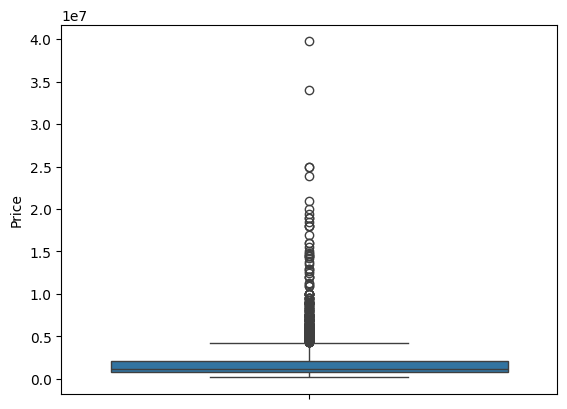

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df['Price'])
plt.show()

In [107]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df['Price']>=lower) & (df['Price']<=upper)]

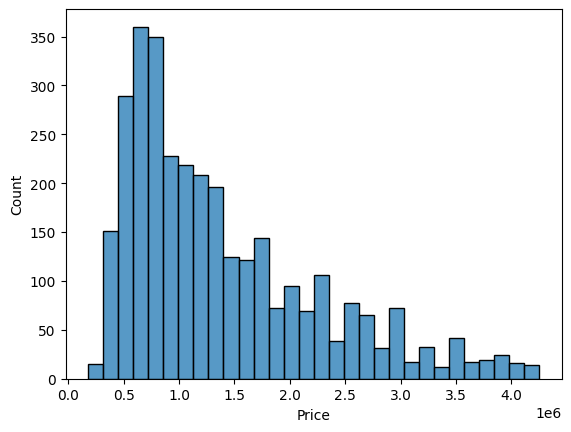

In [108]:
sns.histplot(df['Price'], bins=30)
plt.show()

In [109]:
for col in df.columns:
    print(col)

Unnamed: 0
Property Name
Price
House Type
Area in sq ft
No. of Bedrooms
No. of Bathrooms
No. of Receptions
Location
City/County
Postal Code


<Axes: xlabel='House Type', ylabel='Price'>

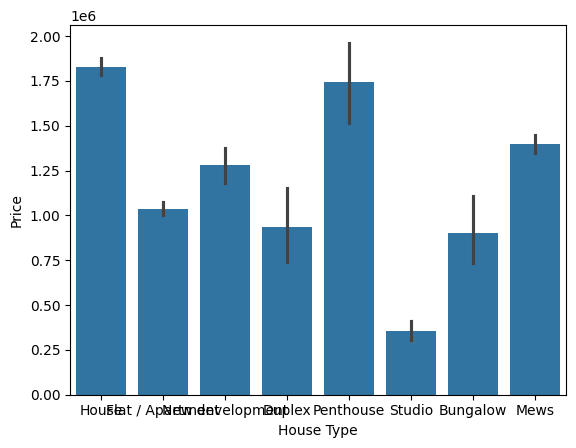

In [110]:
sns.barplot(
x='House Type',
y='Price',
data=df
)

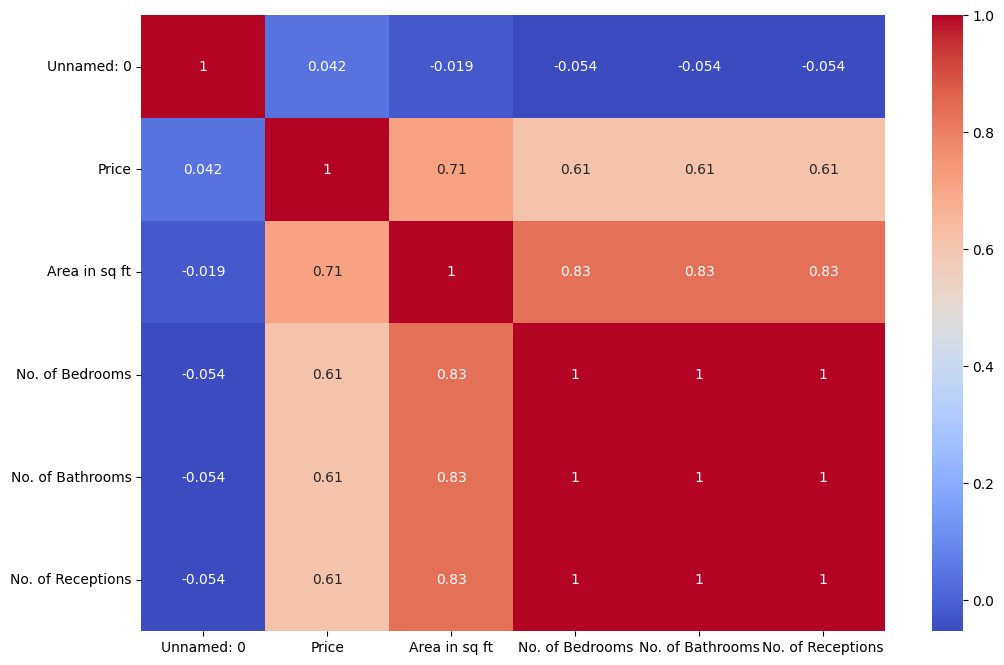

In [111]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr,
annot=True,
cmap='coolwarm')
plt.show()

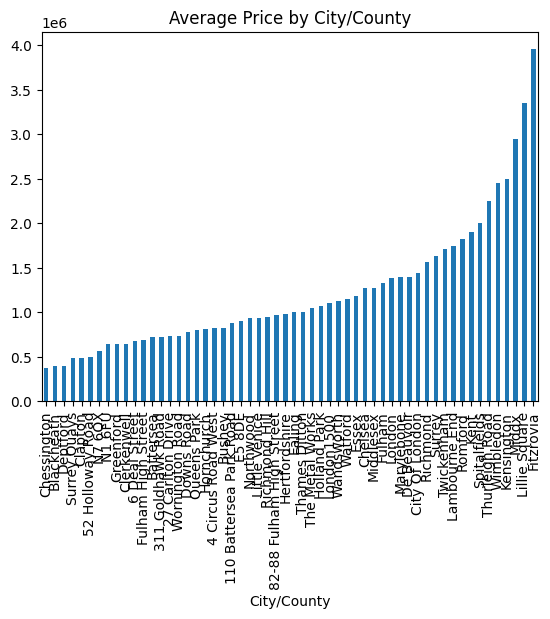

In [112]:
df.groupby('City/County')['Price'].mean().sort_values().plot(kind='bar')
plt.title("Average Price by City/County")
plt.show()

In [113]:
df['Price_Change'] = df['Price'].pct_change()

In [114]:
import numpy as np
df['Total_Rooms'] = (
    df['No. of Bedrooms'] +
    df['No. of Bathrooms'] +
    df['No. of Receptions']
)

df['Price_per_Room'] = df['Price'] / df['Total_Rooms'].replace(0, np.nan)

In [115]:
df = pd.get_dummies(
df,
drop_first=True
)

In [116]:
y = df['Price']
X = df.drop('Price', axis=1)

In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [118]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [142]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [143]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [144]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [145]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [146]:
def evaluate_model(name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-" * 30)

In [147]:

evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("XGBoost", y_test, xgb_pred)

Random Forest
MAE: 19343.504248062014
RMSE: 51653.24795539385
R2 Score: 0.9967364836334203
------------------------------
XGBoost
MAE: 26347.520300387598
RMSE: 49523.88760085211
R2 Score: 0.9970000087829931
------------------------------


<BarContainer object of 5572 artists>

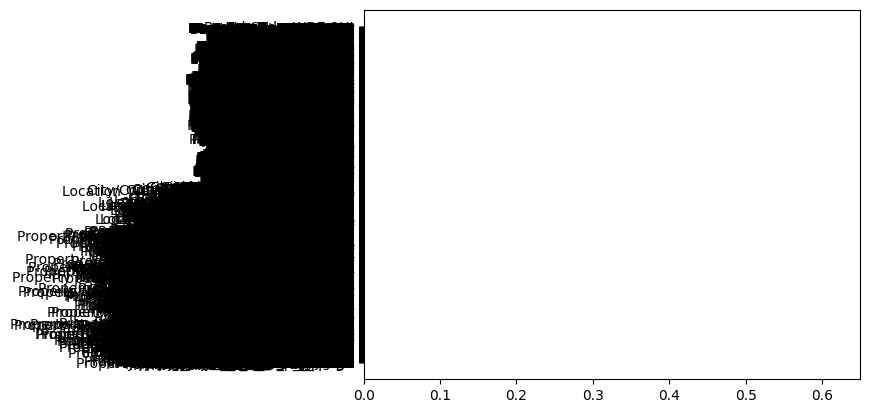

In [148]:
import matplotlib.pyplot as plt

importance = xgb.feature_importances_

plt.barh(
X.columns,
importance
)

In [149]:
import joblib

joblib.dump(
xgb,
"housing_price_model.pkl"
)

['housing_price_model.pkl']